In [ ]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 42.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=ad283c1d8691d57a1fcdf8adb7102bc089cd6bbd77f6c4910da5397ca9c80df5
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/ソーセージ＿画像フォルダー"

/content/drive/MyDrive/ソーセージ＿画像フォルダー


In [ ]:
import cv2
import os
import glob
import numpy as np
from PIL import Image,ImageFile
import matplotlib.pyplot as plt
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
import cv2
regions = ["0_北海道", "1_東北", "2_関東", "3_中部", "4_北陸","5_近畿", "6_中国", "7_四国", "8_九州", "9_沖縄"]

wh = []
ht = []

for region in regions:
  photos = glob.glob(region + "/*.png")
  for file in photos:
      photo = cv2.imread(file)
      if photo is not None:
          h, w = photo.shape[:2]
          wh.append(w)
          ht.append(h)
      else:
          print(f"Warning: Could not read image file: {file}")
ht_resize = int(np.mean(ht))
wh_resize = int(np.mean(wh))
classes = ["0_北海道", "1_東北", "2_関東", "3_中部", "4_北陸","5_近畿", "6_中国", "7_四国", "8_九州", "9_沖縄"]
num_classes = len(classes)

X_train = []
X_test  = []
y_train = []
y_test  = []

for index, classlabel in enumerate(classes):
    photos_dir = "./" + classlabel
    files = glob.glob(photos_dir + "/*.png")
    num_testdata = int(len(files) * 0.2)
    for i, file in enumerate(files):
        image = Image.open(file)
        image = image.convert("RGB")
        image = image.resize((wh_resize//8, ht_resize//8))
        data = np.asarray(image)
        if i < num_testdata: #最初の2割をテストデータに
            X_test.append(data)
            y_test.append(index)
        else: # 残りの8割を訓練データに
            X_train.append(data)
            y_train.append(index)
print(f"平均サイズ: 横{wh_resize}px × 縦{ht_resize}px")
print(f"1/8サイズ: 横{wh_resize//8}px × 縦{ht_resize//8}px")
#Numpy配列に変換
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

#Numpy配列を保存
np.save("./regions_X_train.npy", X_train)
np.save("./regions_X_test.npy", X_test)
np.save("./regions_y_train.npy", y_train)
np.save("./regions_y_test.npy", y_test)

平均サイズ: 横220px × 縦990px
1/8サイズ: 横27px × 縦123px


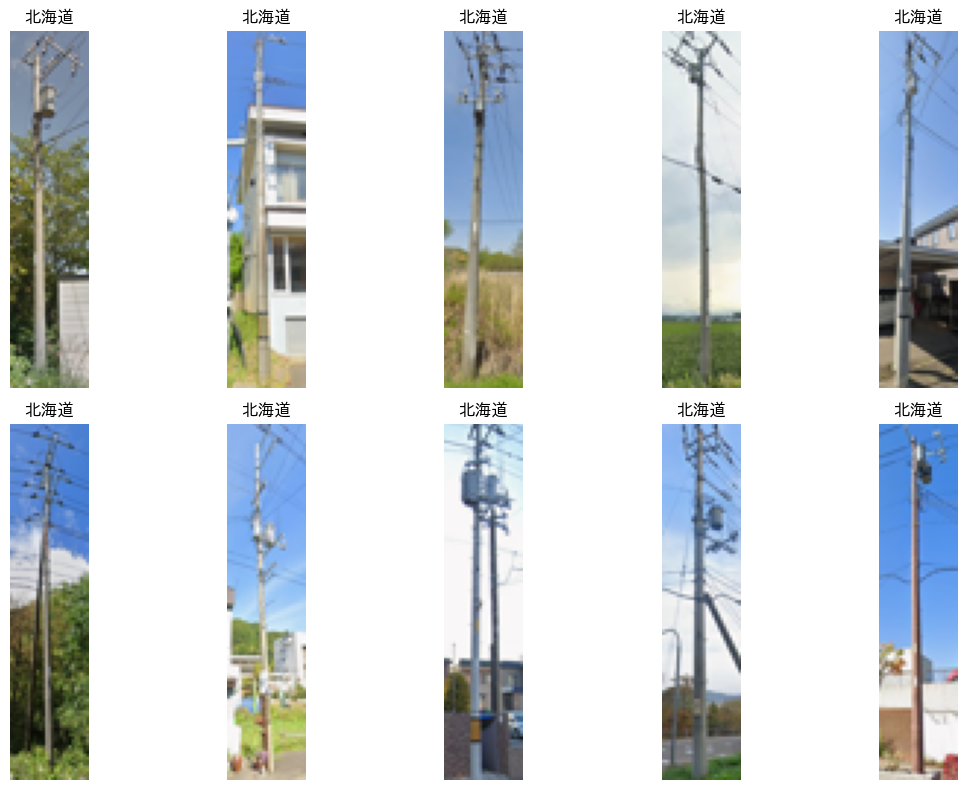

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

X_train = np.load("./regions_X_train.npy")
y_train = np.load("./regions_y_train.npy")

classes = ["北海道", "東北", "関東", "中部", "北陸", "近畿", "中国", "四国", "九州", "沖縄"]

plt.figure(figsize=(12, 8))

# 最初の10枚を表示してみる
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])  # 画像を表示
    plt.title(classes[y_train[i]]) # 対応するラベルを表示
    plt.axis('off') # 軸を非表示にする

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
# 保存した画像データをロード
X_train2 = np.load("./regions_X_train.npy", allow_pickle=True)
X_test2 = np.load("./regions_X_test.npy", allow_pickle=True)
y_train2 = np.load("./regions_y_train.npy", allow_pickle=True)
y_test2 = np.load("./regions_y_test.npy", allow_pickle=True)

X_train2 = X_train2.astype(np.float32) / 255 # 各画素値を0-1の範囲で正規化
X_test2 = X_test2.astype(np.float32) / 255 # 各画素値を0-1の範囲で正規化
y_train2 = y_train2.astype(np.float32)
y_test2 = y_test2.astype(np.float32)
train_dataset = tf.data.Dataset.from_tensor_slices((X_train2, y_train2)) # 訓練データのtf.data.Dataset
test_dataset = tf.data.Dataset.from_tensor_slices((X_test2, y_test2)) # テストデータのtf.data.Dataset

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import matplotlib.pyplot as plt
batch_size = 60 # バッチサイズ
shuffle_buffer_size = len(train_dataset) # データをシャッフルするときのバッファサイズ
epochs = 50 # エポック数
IMG_HEIGHT = ht_resize//8 # 画像の高さ（縦）のサイズ
IMG_WIDTH = wh_resize//8 # 画像の幅（横）のサイズ
train_dataset2 = train_dataset.shuffle(shuffle_buffer_size).batch(batch_size)
test_dataset2 = test_dataset.batch(batch_size)

model = Sequential([
    # 1段目の目（特徴抽出）
    Conv2D(8, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # 2段目の目（より複雑な特徴を探す）
    Conv2D(16, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # 3段目の目（さらに深く！）
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # 判定層へ
    Flatten(),
    Dense(32, activation='relu'),
    BatchNormalization(), # ここにも入れると効果的
    Dropout(0.5),         # 演習⑥の過学習防止も忘れずに
    Dense(10, activation='softmax') # 10クラス分類の場合
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # ラベルが整数値なので、"sparse_"を付ける
              metrics=['accuracy'])

In [ ]:
history=model.fit(train_dataset2, epochs=epochs, validation_data=test_dataset2)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1181 - loss: 3.2133 - val_accuracy: 0.1389 - val_loss: 2.2912
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1944 - loss: 2.5993 - val_accuracy: 0.2222 - val_loss: 2.2935
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1944 - loss: 2.4865 - val_accuracy: 0.1667 - val_loss: 2.2939
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2917 - loss: 2.1633 - val_accuracy: 0.0556 - val_loss: 2.2955
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2847 - loss: 2.1027 - val_accuracy: 0.1111 - val_loss: 2.2968
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2986 - loss: 1.9289 - val_accuracy: 0.1111 - val_loss: 2.3009
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3681 - loss: 1.9178 - val_accuracy: 0.1389 - val_loss: 2.3067
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4028 - loss: 1.8183 - val_accuracy: 0.1111 - val_loss: 2.3115
Epoc

5. 学習結果をグラフで表示します...


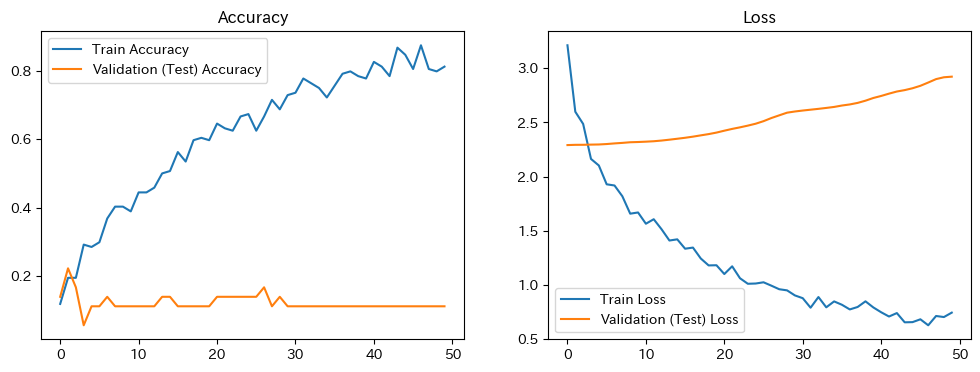

6. テストデータでの最終評価...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1111 - loss: 2.9233


[2.9233131408691406, 0.1111111119389534]

In [ ]:
print("5. 学習結果をグラフで表示します...")
# 学習の推移をグラフ化
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation (Test) Loss')
plt.legend()
plt.title('Loss')
plt.show()

print("6. テストデータでの最終評価...")
model.evaluate(test_dataset2)